# Apples to apples: what run11 and AVES actually cost

Two encoders are compared throughout this project:

| | pretraining corpus | initialisation |
|---|---|---|
| **run11** | 116 h of zebra-finch colony audio | random |
| **aves-base-bio** | 360 h of general animal/environmental audio | random |

They are the **same network** — `torchaudio.models.hubert_pretrain_base` / fairseq `hubert_base`,
94,370,944 parameters, bit-identical `state_dict` keys. Architecture is not a variable here. What
differs is the corpus, the schedule, and the k-means targets the masked-prediction loss is fitted to.

This notebook answers one question the project got **wrong** for a while: *how much training did each
one actually get?* Every number is read from `paper/results.json`, the audited registry — nothing in
this notebook is typed by hand.

In [1]:
import json, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
REG  = json.load(open(REPO / "paper/results.json"))
E    = REG["entries"]
print(f"registry: {REG['n_entries']} entries, built {REG['generated']}")

def R(key, fmt=None):
    # Fetch an audited value. Raises on a missing key so a typo can never become a silent 0.
    if key not in E:
        raise KeyError(f"{key} is not in the registry; run paper/build_registry.py")
    v = E[key]
    val = v["value"] if isinstance(v, dict) else v
    return format(val, fmt) if fmt else val

def note(key):
    v = E.get(key)
    return (v.get("note") or "") if isinstance(v, dict) else ""

registry: 274 entries, built 2026-09-16T21:01:07


## 1. The correction: requested resources are not realised resources

run11's SLURM script asks for four L40 GPUs:

```bash
#SBATCH --gres=gpu:L40:4
#SBATCH --ntasks=1          # <-- this is the problem
...
    --gpus 4 \
```

`--ntasks=1` means `srun` launches **one** task, so Lightning initialises with `world_size 1` and
trains on a single device. The other three GPUs are reserved and idle. Observed live on a job running
this same script:

```
index, name,        utilization.gpu, memory.used
0,     NVIDIA L40S, 90 %,            9939 MiB
1,     NVIDIA L40S,  0 %,               3 MiB
2,     NVIDIA L40S,  0 %,               3 MiB
3,     NVIDIA L40S,  0 %,               3 MiB
```

The log says it plainly, if you read the two lines together:

```
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
All distributed processes registered. Starting with 1 processes
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
```

So the earlier budget — which computed audio-per-step as `--gpus × --seconds-per-batch` = 4 × 87.5 =
350 — was wrong by 4×. Compounding it, the corpus was taken from the release README's round "~100 h"
when the training TSV says otherwise.

In [2]:
# The ledger that settles it: run11's own checkpoint filenames on scratch.
# Consecutive (epoch, step) differences ARE steps-per-epoch -- free, and authoritative.
ledger = [(14, 78029), (15, 83230), (16, 88432), (17, 93633), (18, 93750)]
d = pd.DataFrame(ledger, columns=["epoch", "global_step"])
d["steps_since_prev"] = d.global_step.diff()
display(d)

deltas = d.steps_since_prev.dropna()
full   = deltas[deltas > 0.5 * deltas.max()]          # drop the final epoch, truncated by max-updates
spe    = full.mean()
corpus_s = R("budget.run11.corpus_hours") * 3600
print(f"steps per epoch      : {spe:,.2f}   (from {len(full)} complete epochs)")
print(f"corpus               : {corpus_s:,.0f} s = {R('budget.run11.corpus_hours'):.2f} h")
print(f"realised audio/step  : {corpus_s/spe:,.2f} s   <- NOT 4 x 87.5 = 350")
print(f"epochs at 93,750 steps: {R('budget.run11.updates')/spe:,.2f}  "
      f"vs Lightning's recorded {d.epoch.max()}")

,epoch,global_step,steps_since_prev
0,14,78029,NaN
1,15,83230,5201.0
2,16,88432,5202.0
3,17,93633,5201.0
4,18,93750,117.0


steps per epoch      : 5,201.33   (from 3 complete epochs)
corpus               : 417,703 s = 116.03 h
realised audio/step  : 80.31 s   <- NOT 4 x 87.5 = 350
epochs at 93,750 steps: 18.02  vs Lightning's recorded 18


### The check that would have caught it immediately

The budget script *had* a self-check: derive epochs as `(steps × audio-per-step) / corpus-hours` and
compare against the epoch counter the framework itself recorded. It was applied **only to AVES**.
Run symmetrically, run11's derived 91.1 epochs against its recorded 18 fails instantly.

`compute_budget.py` now asserts it for every arm. Asymmetric validation is how a 5× error survives a
script explicitly designed to be self-checking.

In [3]:
rows = [
    ("optimiser steps",            R("budget.run11.updates"),        R("budget.aves.updates"),        "{:,.0f}"),
    ("audio-seconds per step",     R("budget.run11.sec_per_update"), R("budget.aves.sec_per_update"), "{:,.1f}"),
    ("TOTAL audio seen (h)",       R("budget.run11.audio_hours"),    R("budget.aves.audio_hours"),    "{:,.1f}"),
    ("pretraining corpus (h)",     R("budget.run11.corpus_hours"),   R("budget.aves.corpus_hours"),   "{:,.2f}"),
    ("epochs over own corpus",     R("budget.run11.epochs"),         R("budget.aves.epochs"),         "{:,.1f}"),
    ("peak learning rate",         1e-4,                              2e-4,                            "{:.1e}"),
    ("warmup fraction",            R("budget.run11.warmup_frac"),    R("budget.aves.warmup_frac"),    "{:.3f}"),
    ("k-means clusters",           100,                               200,                             "{:,.0f}"),
]
tbl = pd.DataFrame(
    [(n, f.format(a), f.format(b), f"{b/a:.2f}x") for n, a, b, f in rows],
    columns=["", "run11", "aves-base-bio", "AVES / run11"]).set_index("")
display(tbl)
print(f"GPUs: run11 reserved 4 and used {R('budget.run11.world_size')};  "
      f"AVES used 1 with update_freq 8.")
print("\nBoth arms now pass the epoch self-check:")
print(f"  run11  derived {R('budget.run11.epochs'):.2f} vs recorded 18  -> {abs(R('budget.run11.epochs')-18)/18*100:.1f}% apart")
print(f"  aves   derived {R('budget.aves.epochs'):.2f} vs recorded 55  -> {abs(R('budget.aves.epochs')-55)/55*100:.1f}% apart")

,run11,aves-base-bio,AVES / run11
,,,
optimiser steps,"93,750","100,000",1.07x
audio-seconds per step,80.3,700.0,8.72x
TOTAL audio seen (h),"2,091.3","19,444.4",9.30x
pretraining corpus (h),116.03,360.00,3.10x
epochs over own corpus,18.0,54.0,3.00x
peak learning rate,1.0e-04,2.0e-04,2.00x
warmup fraction,0.033,0.320,9.60x
k-means clusters,100,200,2.00x


GPUs: run11 reserved 4 and used 1;  AVES used 1 with update_freq 8.

Both arms now pass the epoch self-check:
  run11  derived 18.02 vs recorded 18  -> 0.1% apart
  aves   derived 54.01 vs recorded 55  -> 1.8% apart


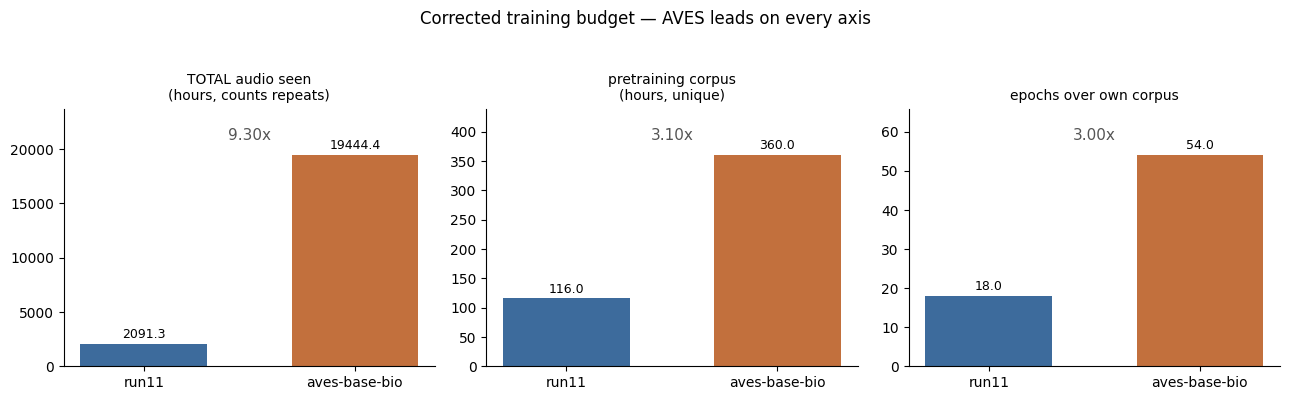

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
pairs = [("TOTAL audio seen\n(hours, counts repeats)", R("budget.run11.audio_hours"), R("budget.aves.audio_hours")),
         ("pretraining corpus\n(hours, unique)",       R("budget.run11.corpus_hours"), R("budget.aves.corpus_hours")),
         ("epochs over own corpus",                    R("budget.run11.epochs"),       R("budget.aves.epochs"))]
for a, (title, v11, vav) in zip(ax, pairs):
    bars = a.bar(["run11", "aves-base-bio"], [v11, vav], color=["#3d6b9c", "#c2703d"], width=.6)
    a.set_title(title, fontsize=10)
    a.bar_label(bars, fmt="%.1f", fontsize=9, padding=2)
    a.set_ylim(0, max(v11, vav) * 1.22)
    a.spines[["top", "right"]].set_visible(False)
    a.text(.5, .88, f"{vav/v11:.2f}x", transform=a.transAxes, ha="center",
           fontsize=11, color="#555")
fig.suptitle("Corrected training budget — AVES leads on every axis", y=1.04, fontsize=12)
plt.tight_layout(); plt.show()

**Conclusion of part 1.** run11 is under-trained on *both* axes: it saw **9.30×** less audio and made
**3.00×** fewer passes over its own corpus. The previous claim — that run11 made 1.7× *more* passes
and was therefore "under-diversified, not under-trained" — is refuted (finding 041 → 044).

Note the two axes measure different things. *Audio seen* counts repeats, so it is a **compute**
measure. *Corpus hours* is the **data diversity** measure. Here both favour AVES, which is why the
conclusion is unambiguous where the earlier one was not.

## 2. Apples to apples: what did that buy?

Now the other half. AVES had 3.1× the data and 9.3× the compute — how much better is it?

Every delta below is a **cluster bootstrap**: over the 26 birds for call type, over 1500-frame (30 s)
blocks for detection, because neighbouring frames are heavily correlated and a naive per-frame
bootstrap would badly understate the interval.

In [5]:
perf = pd.DataFrame([
    ("Detection, in-distribution (AUC)", R("aves.zf.run11_L0.auc"), R("aves.zf.best_aves.auc"),
     R("ens.boot.aves_vs_run11.auc"), R("ens.boot.aves_vs_run11.lo"), R("ens.boot.aves_vs_run11.hi")),
    ("Call type, 11-class, released feats", R("ct11.run11.best_acc"), R("ct11.aves.best_acc"),
     -R("ct11.boot.run11_vs_aves"), -R("ct11.boot.run11_vs_aves.hi"), -R("ct11.boot.run11_vs_aves.lo")),
    ("Call type, 8-class, extraction matched", R("ct8m.run11.best_acc"), R("ct8m.aves.best_acc"),
     -R("ct8m.boot.run11_vs_aves"), -R("ct8m.boot.run11_vs_aves.hi"), -R("ct8m.boot.run11_vs_aves.lo")),
    ("Detection, BirdPark holdout (AUC)", R("aves.bp.run11_L0.auc"), R("aves.bp.aves_L6.auc"),
     R("ens.bp.boot.aves_vs_run11"), np.nan, np.nan),
], columns=["protocol", "run11", "AVES", "delta_AVES_minus_run11", "lo", "hi"])

def verdict(r):
    if np.isnan(r.lo): return "not distinguishable (low power)"
    return "AVES wins" if r.lo > 0 else ("run11 wins" if r.hi < 0 else "not distinguishable")
perf["95% CI"] = [("—" if np.isnan(r.lo) else f"[{r.lo:+.4f}, {r.hi:+.4f}]") for r in perf.itertuples()]
perf["verdict"] = [verdict(r) for r in perf.itertuples()]
display(perf[["protocol", "run11", "AVES", "delta_AVES_minus_run11", "95% CI", "verdict"]]
        .style.format({"run11": "{:.4f}", "AVES": "{:.4f}", "delta_AVES_minus_run11": "{:+.4f}"}))
print("\nBirdPark caveat:", note("aves.bp.n_frames"), f"(n={R('aves.bp.n_frames')} frames)")
print("Extraction-matched caveat:", note("ct8m.boot.run11_vs_aves"))

,protocol,run11,AVES,delta_AVES_minus_run11,95% CI,verdict
0,"Detection, in-distribution (AUC)",0.9687,0.9674,-0.0002,"[-0.0030, +0.0025]",not distinguishable
1,"Call type, 11-class, released feats",0.8118,0.8453,+0.0338,"[+0.0069, +0.0609]",AVES wins
2,"Call type, 8-class, extraction matched",0.8193,0.8359,+0.0169,"[-0.0041, +0.0400]",not distinguishable
3,"Detection, BirdPark holdout (AUC)",0.8649,0.8830,+0.0161,—,not distinguishable (low power)



BirdPark caveat: why the holdout bootstrap has no power (n=5925 frames)
Extraction-matched caveat: NOT distinguishable once extraction is matched


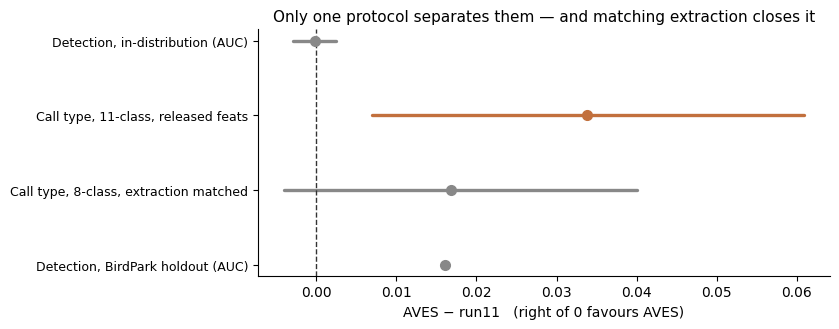

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
y = np.arange(len(perf))[::-1]
for i, r in zip(y, perf.itertuples()):
    col = "#c2703d" if (not np.isnan(r.lo) and r.lo > 0) else "#888"
    if not np.isnan(r.lo):
        ax.plot([r.lo, r.hi], [i, i], color=col, lw=2.4, solid_capstyle="round")
    ax.plot(r.delta_AVES_minus_run11, i, "o", color=col, ms=7, zorder=3)
ax.axvline(0, color="#333", lw=1, ls="--")
ax.set_yticks(y); ax.set_yticklabels(perf.protocol, fontsize=9)
ax.set_xlabel("AVES − run11   (right of 0 favours AVES)")
ax.set_title("Only one protocol separates them — and matching extraction closes it", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Reading this honestly

Three of four protocols show **no distinguishable difference**, achieved with 3.1× less data and
9.3× less compute. That is a genuine efficiency result.

Three caveats keep it from being more than that:

1. **"Not distinguishable" is not "equal."** BirdPark in particular has almost no power — 5,925
   scorable frames — so it cannot resolve a difference in either direction.
2. **The one clear AVES win shrinks when extraction is matched.** 11-class released features give
   AVES +0.0338 (significant); the 8-class arm with both encoders extracted identically gives
   +0.0169 (not significant). That points at a feature-extraction artifact more than a
   representation gap.
3. **The corpora are not equally relevant.** run11's 116 h is zebra-finch audio for a zebra-finch
   task; AVES's 360 h is generic. Per hour, in-domain data should be worth more — so part of run11's
   apparent efficiency is domain match, which is the very variable the project set out to measure.

Read one way: *run11 is ~9× more compute-efficient.* Read the other: *run11 had the home-field
advantage and still wins nowhere.* Both readings are supported. What the corrected budget changes is
that the first reading is now **open** — previously the (wrong) numbers foreclosed it.

## 3. What is still untested: run11's ceiling

run11 was never trained to convergence against a comparable budget. And testing that is nearly free,
because the job was already *reserving* four GPUs and using one — fixing `#SBATCH --ntasks=4` gives
4× the audio per step at the same wall clock and the same reservation.

In [7]:
spb_nominal = 87.5
scaled = R("budget.run11.sec_per_update") * 4          # same realised efficiency, 4 ranks
proj = pd.DataFrame([
    ("run11 as-run (1 GPU)",           R("budget.run11.sec_per_update"), R("budget.run11.audio_hours"), R("budget.run11.epochs")),
    ("run11 on 4 GPUs, same steps",    scaled, scaled*R("budget.run11.updates")/3600, scaled*R("budget.run11.updates")/3600/R("budget.run11.corpus_hours")),
    ("aves-base-bio",                  R("budget.aves.sec_per_update"), R("budget.aves.audio_hours"), R("budget.aves.epochs")),
], columns=["configuration", "audio-sec/step", "total audio (h)", "epochs over own corpus"])
display(proj.style.format({"audio-sec/step": "{:,.1f}", "total audio (h)": "{:,.0f}",
                           "epochs over own corpus": "{:,.1f}"}).hide(axis="index"))
print("Closes most of the compute gap inside the same 12 h job.")
print("Caveat: 4x the batch usually wants a higher LR, and LR is the variable that already cost")
print("this project five runs (5e-4 plateau, runs 5-9). Hold LR at 1e-4 first; treat any plateau")
print("as an LR question before concluding anything about capacity.")

configuration,audio-sec/step,total audio (h),epochs over own corpus
run11 as-run (1 GPU),80.3,"2,091",18.0
"run11 on 4 GPUs, same steps",321.2,"8,365",72.1
aves-base-bio,700.0,"19,444",54.0


Closes most of the compute gap inside the same 12 h job.
Caveat: 4x the batch usually wants a higher LR, and LR is the variable that already cost
this project five runs (5e-4 plateau, runs 5-9). Hold LR at 1e-4 first; treat any plateau
as an LR question before concluding anything about capacity.


---

**Provenance.** Budget: `zfeval/experiments/compute_budget.py` → `analysis/compute_budget.json`.
Performance: `aves_baseline.py`, `aves_holdout.py`, `calltype11.py`, `ensemble_detect.py`.
Findings: `knowledge/findings/044` (corrected budget, supersedes the refuted `041`),
`030`/`033`/`035`/`036` (the run11-vs-AVES protocols).

The companion notebook `02_dapt_general_then_specialize.ipynb` covers the other half of your
question: using AVES as a general-purpose first pass and then specialising on zebra finch.